# Import Libraries

In [20]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Helper function to select price data

In [21]:
def select_price_frame(df, tickers):
    """
    Return a DataFrame of adjusted close (preferred) or close prices,
    handling both MultiIndex and single-index column formats from yfinance.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise ValueError("Downloaded data is empty.")

    # If MultiIndex columns (common for multiple tickers)
    if isinstance(df.columns, pd.MultiIndex):
        levels = [set(df.columns.get_level_values(i)) for i in range(df.columns.nlevels)]

        # Find which level has field names
        field_level = None
        for lvl, names in enumerate(levels):
            if "Adj Close" in names or "Close" in names:
                field_level = lvl
                break

        if field_level is None:
            raise KeyError("Neither 'Adj Close' nor 'Close' found in downloaded columns.")

        # Prefer Adj Close, else fall back to Close
        field_name = "Adj Close" if "Adj Close" in levels[field_level] else "Close"
        prices = df.xs(field_name, level=field_level, axis=1)

        # Keep only requested tickers (some may be missing)
        prices = prices[[t for t in tickers if t in prices.columns]]

        if prices.empty:
            raise KeyError(f"No price columns found for requested tickers: {tickers}")

        return prices

    # Single-index columns (can happen if only one ticker or older behavior)
    else:
        # If it already looks like a matrix of tickers
        if set(tickers).issubset(set(df.columns)):
            return df[tickers]

        # Otherwise try typical field names
        for candidate in ["Adj Close", "Close"]:
            if candidate in df.columns:
                s = df[candidate]
                # If it's a Series (single ticker), make it a 1-col DF
                if isinstance(s, pd.Series):
                    s = s.to_frame(name=tickers[0] if len(tickers) == 1 else candidate)
                return s

        raise KeyError("Could not locate 'Adj Close' or 'Close' in single-index columns.")

# Download data

In [22]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']

# Be explicit about params to reduce surprises across yfinance versions
raw = yf.download(
    tickers,
    start='2022-01-01',
    end='2025-01-01',
    group_by='column',      # yfinance default, but explicit
    auto_adjust=False,      # keep Adj Close separate
    progress=True
)

# Extract a clean price matrix
data = select_price_frame(raw, tickers)

[*********************100%***********************]  4 of 4 completed


# Calculate returns and statistics

In [23]:
# Compute returns
returns = data.pct_change().dropna(how='all')
returns = returns.dropna(axis=1, how='all')  # drop any ticker that has all NaNs

if returns.shape[1] == 0:
    raise ValueError("No valid return series after cleaning. Check tickers/data availability.")

# Mean returns & covariance
mean_returns = returns.mean()
cov_matrix = returns.cov()

# Portfolio performance functions

In [24]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    p_ret = float(np.sum(mean_returns * weights) * 252)  # annualized return
    p_vol = float(np.sqrt(weights.T @ (cov_matrix * 252) @ weights))  # annualized vol
    return p_ret, p_vol

def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    p_ret, p_vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_vol

# Optimise portfolio

In [25]:
num_assets = len(mean_returns)
bounds = tuple((0.0, 1.0) for _ in range(num_assets))
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
init_guess = np.full(num_assets, 1.0 / num_assets)

opt = minimize(
    negative_sharpe,
    init_guess,
    args=(mean_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-9}
)

if not opt.success:
    raise RuntimeError(f"Optimization failed: {opt.message}")

optimal_weights = opt.x
opt_return, opt_volatility = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
sharpe_ratio = (opt_return - 0.02) / opt_volatility

# Display results

In [26]:
cols = list(mean_returns.index)
print("Optimal Portfolio Weights:")
for t, w in zip(cols, optimal_weights):
    print(f"  {t}: {w:.2%}")
print(f"Expected Annual Return: {opt_return:.2%}")
print(f"Annual Volatility:      {opt_volatility:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.2f}")

Optimal Portfolio Weights:
  AAPL: 72.23%
  MSFT: 0.00%
  GOOGL: 14.39%
  AMZN: 13.37%
Expected Annual Return: 14.95%
Annual Volatility:      26.28%
Sharpe Ratio:           0.49


# Plot efficient frontier

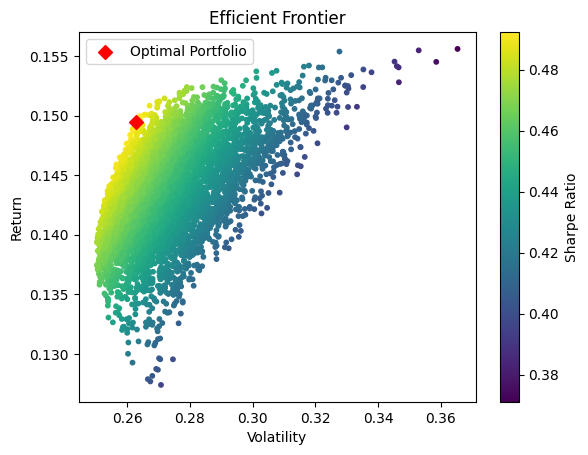

In [27]:
def simulate_random_portfolios(num_portfolios, mean_returns, cov_matrix, risk_free_rate=0.02):
    results = np.zeros((3, num_portfolios))
    weights_record = []

    for i in range(num_portfolios):
        weights = np.random.random(len(mean_returns))
        weights /= np.sum(weights)
        weights_record.append(weights)
        p_return, p_std_dev = portfolio_performance(weights, mean_returns, cov_matrix)
        results[0,i] = p_std_dev
        results[1,i] = p_return
        results[2,i] = (p_return - risk_free_rate) / p_std_dev
    
    return results, weights_record

results, weights = simulate_random_portfolios(5000, mean_returns, cov_matrix)

plt.scatter(results[0], results[1], c=results[2], cmap='viridis', marker='o', s=10)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.scatter(opt_volatility, opt_return, c='red', marker='D', s=50, label='Optimal Portfolio')
plt.legend()
plt.show()
